In [125]:
from Bio import Entrez, SeqIO
from Bio import Align
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

In [10]:
# -------------------------
# Part 1: 從NCBI下載資料
# -------------------------

#由於NCBI資料量龐大，從https://viralzone.expasy.org/9556中取得NCBI編號
#由左至右為原始株、Delta、BA.1、BA.2、BA.5的spike protein序列
ids = ["YP_009724390.1", "QUD52764.1", "UFO69279.1", "UJP23605.1", "UOZ45804.1"]

#給信箱作為身分驗證，當存取行為異常時才能收到通知
Entrez.email = "tiffanyhong911201@gmail.com"

#選FASTA格式是因為他僅包含序列內容，不包含其他資訊，所以讀取速度最快
all_sequence = {}
for i in ids:
    record_search = Entrez.efetch(db="protein", id=i, rettype="fasta", retmode="text")
    try:
        record = SeqIO.read(record_search, "fasta")
        all_sequence[i] = record
    finally:  #強制檔案關起來
        record_search.close()
    
    #開檔案將字典中的序列資列存入
    filename = f"{i}.faa"
    try:
        file = open(filename,'w')
        SeqIO.write(record, file, "fasta")
    finally:
        file.close()

    all_sequence[i] = record
print("---下載完畢---")

---下載完畢---


In [215]:
# ---------------------
# Part 2: 進行alignment
# ---------------------

#由於變異株之間差異小，因此使用global alignment，和WT進行比對
aligner = Align.PairwiseAligner()
aligner.mode = 'global'

name_pairing = {
    "YP_009724390.1": "Wild Type", 
    "QUD52764.1": "Delta",
    "UFO69279.1": "BA.1",
    "UJP23605.1": "BA.2",
    "UOZ45804.1": "BA.5"
}

ref_id = "YP_009724390.1"
ref_record = all_sequence[ref_id]

total_mutation = []


for i in ids:
    
    if i == ref_id:
        continue
        
    #進行align
    target_record = all_sequence[i]
    alignment = aligner.align(ref_record.seq, target_record.seq)
    best_align = alignment[0]
    align_ref, align_target = best_align

    #設定紀錄mutation和insertion的字典、列表
    number_counter = 0
    individual_mutation = {"Variant": name_pairing[i]}
    insert_seq = []
    insert_seq_total = {"Variant": name_pairing[i]}
    
    #針對已align的序列區分deletion、insertion、substitution狀況，用於後續製作圖表
    for j in range(0, len(align_ref)):
        aac_ref = align_ref[j]
        aac_target = align_target[j]

        #結算insert_seq的數量，且將insert位置標示為某位點之後
        if aac_ref != "-":
            if len(insert_seq) > 0:
                insert_seq_total[f"{number_counter}insert"] = "".join(insert_seq)
                insert_seq = []
            number_counter += 1

        if aac_ref != aac_target:
            
            #Deletion
            if aac_target == "-":
                individual_mutation[f"{aac_ref}{number_counter}"] = "Del"
    
            #insertion
            elif aac_ref == "-":
                insert_seq.append(aac_target)

            #substitution
            else:
                individual_mutation[f"{aac_ref}{number_counter}"] = aac_target

    total_mutation.append(individual_mutation)

    #處理末端超出ref長度的insertion
    if len(insert_seq) > 0:
        insert_seq.append(align_target[number_counter-1:])
        insert_seq_total[f"{number_counter}insert"] = "".join(insert_seq)
    
#處理回傳mutation的列表
if len(total_mutation) > 0:
    for i in range(0, len(total_mutation)):
        print(total_mutation[i])
else:
   print(total_mutation, "無突變位點")     
        

{'Variant': 'Delta', 'T19': 'R', 'K77': 'T', 'E156': 'G', 'F157': 'Del', 'R158': 'Del', 'L452': 'R', 'T478': 'K', 'D614': 'G', 'P681': 'R', 'D950': 'N'}
{'Variant': 'BA.1', 'A67': 'V', 'H69': 'Del', 'V70': 'Del', 'T95': 'I', 'G142': 'D', 'V143': 'Del', 'Y144': 'Del', 'Y145': 'Del', 'N211': 'I', 'L212': 'Del', 'G339': 'D', 'S371': 'L', 'S373': 'P', 'S375': 'F', 'K417': 'N', 'N440': 'K', 'G446': 'S', 'S477': 'N', 'T478': 'K', 'E484': 'A', 'Q493': 'R', 'G496': 'S', 'Q498': 'R', 'N501': 'Y', 'Y505': 'H', 'T547': 'K', 'D614': 'G', 'H655': 'Y', 'N679': 'K', 'P681': 'H', 'N764': 'K', 'D796': 'Y', 'N856': 'K', 'Q954': 'H', 'N969': 'K', 'L981': 'F'}
{'Variant': 'BA.2', 'T19': 'I', 'L24': 'S', 'P25': 'Del', 'P26': 'Del', 'A27': 'Del', 'G142': 'D', 'V213': 'G', 'G339': 'D', 'S371': 'F', 'S373': 'P', 'S375': 'F', 'T376': 'A', 'D405': 'N', 'R408': 'S', 'K417': 'N', 'N440': 'K', 'S477': 'N', 'T478': 'K', 'E484': 'A', 'Q493': 'R', 'Q498': 'R', 'N501': 'Y', 'Y505': 'H', 'D614': 'G', 'H655': 'Y', 'N679

In [217]:
# --------------------------------------------------
# Part 3: 將mutation處依照位點由小到大排列，並建立表格
# --------------------------------------------------

#將有發生變異的位點丟入set集合，並將其轉換為list
mutation_set = set()
for i in total_mutation:
    for j in i:
        if j != "Variant":
            mutation_set.add(j)
            
mutation_list = list(mutation_set)

#將變異後形成的氨基酸種類丟入set集合
mutation_aac = set()
for i in total_mutation:
    for j in i:
        if j != "Variant":
            mutation_aac.add(i[j])

mutation_aac = list(mutation_aac)

#將set集合中的元素按照位點由小到大排列成list
def sort_by_num(a):
    
    mutation_dict = {}
    sorted_mutation_list = []     #用來當圖表的column
    
    for i in range(0,len(a)):
        mutation_list_temp = []
        for j in range(0, len(a[i])):
            if a[i][j].isdigit():
                mutation_list_temp.append(a[i][j])    
        mutation_dict[int("".join(mutation_list_temp))] = a[i]
        
    for k in sorted(mutation_dict):
        sorted_mutation_list.append(mutation_dict[k])
    
    return sorted_mutation_list

sorted_mutation_list = sort_by_num(mutation_list)

#total_mutation是含有字典的list，因此內建模式是將每個字典作為row的一筆筆資料、key作為column名稱
df = pd.DataFrame(total_mutation)

#將variant名稱設為index編號、直接在df中進行更改
df.set_index('Variant', inplace=True)

#在原先的column名稱中挑選出s...list中所含有的，並依這順序排列
df = df[sorted_mutation_list]

#避免畫圖時遇到NaN會出錯，改填WT
df = df.fillna("WT")
print(df)

        T19 L24  P25  P26  A27 A67  H69  V70 T76 K77  ... H655 N679 P681 N764  \
Variant                                               ...                       
Delta     R  WT   WT   WT   WT  WT   WT   WT  WT   T  ...   WT   WT    R   WT   
BA.1     WT  WT   WT   WT   WT   V  Del  Del  WT  WT  ...    Y    K    H    K   
BA.2      I   S  Del  Del  Del  WT   WT   WT  WT  WT  ...    Y    K    H    K   
BA.5      I   S  Del  Del  Del  WT  Del  Del   I  WT  ...    Y    K    H    K   

        D796 N856 D950 Q954 N969 L981  
Variant                                
Delta     WT   WT    N   WT   WT   WT  
BA.1       Y    K   WT    H    K    F  
BA.2       Y   WT   WT    H    K   WT  
BA.5       Y   WT   WT    H    K   WT  

[4 rows x 53 columns]


{'WT': 0, 'T': 1, 'S': 2, 'G': 3, 'A': 4, 'K': 5, 'Del': 6, 'F': 7, 'R': 8, 'P': 9, 'V': 10, 'H': 11, 'N': 12, 'L': 13, 'Y': 14, 'I': 15, 'D': 16}


C:\Users\tiffany\AppData\Local\Temp\ipykernel_54216\1997700595.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  numeric_df = df.replace(map_dict)


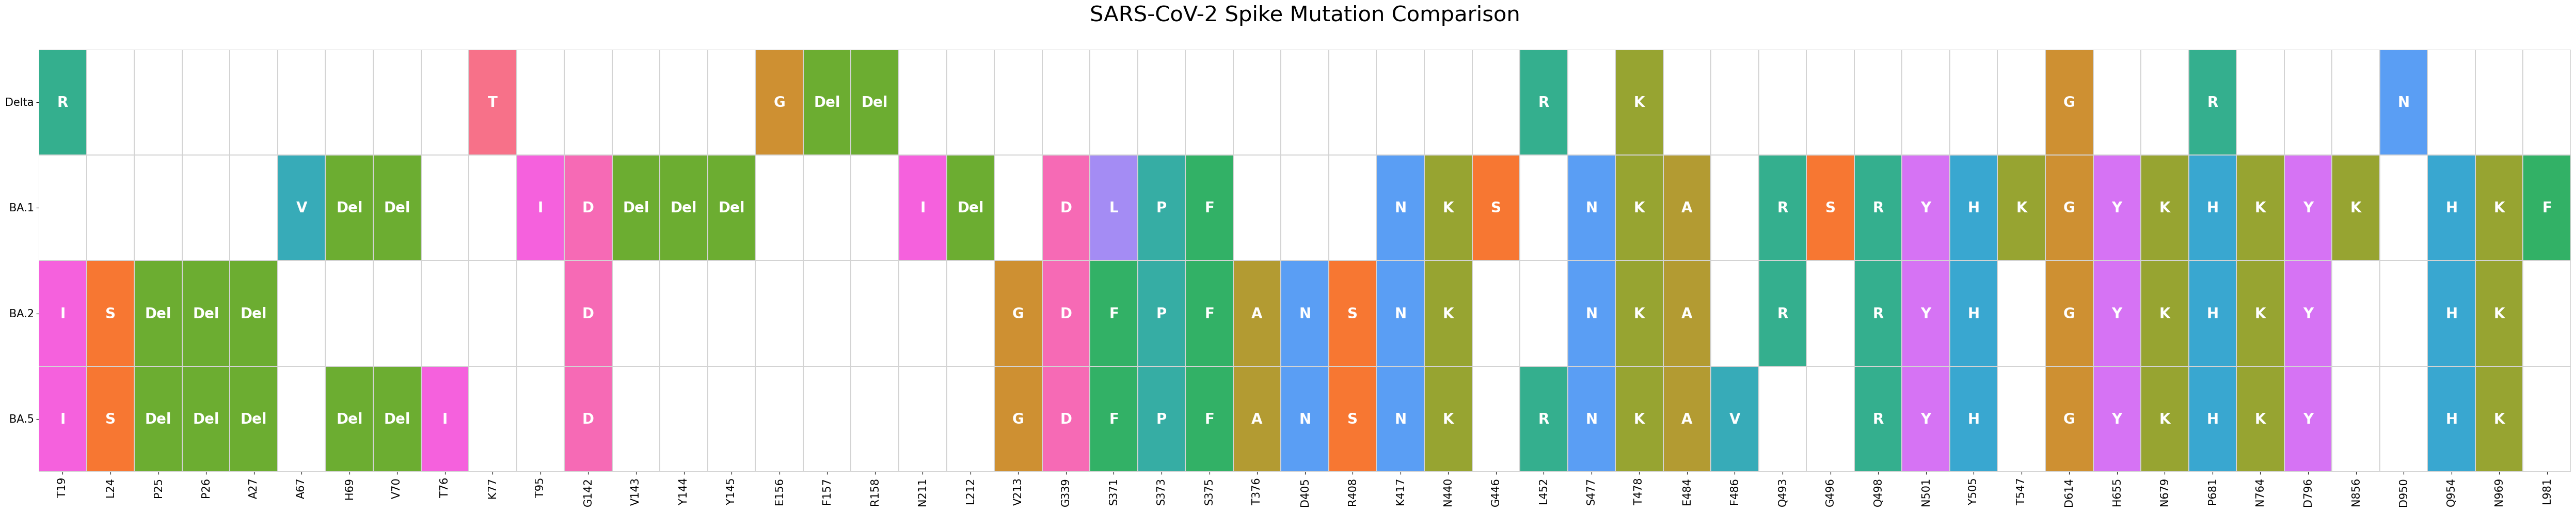

In [257]:
# ---------------------------
# Part 4: 利用df的資料繪圖
# ---------------------------

plt.figure(figsize=(50,10))

total_aac = ['WT'] + mutation_aac
map_dict = {}
for num, label in enumerate(total_aac):
    map_dict[label] = num
print(map_dict)
numeric_df = df.replace(map_dict)

#cmap只認得Colormap物件，不認得單純的顏色清單
color_num = len(total_aac)
other_mut_color = sns.color_palette('husl', color_num-1)
mut_color = ['white'] + list(other_mut_color)
color_map = ListedColormap(mut_color)

no_wt_df = df.replace('WT', '')

#設定圖內容
pic = sns.heatmap(
numeric_df, 
cmap=color_map, 
linewidths=0.3, 
linecolor='lightgray', 
cbar=False, 
annot=no_wt_df, #指定標註內容
fmt="", #格式設定為空 (因為標註的是字串不是數字)
annot_kws={ #調整文字樣式
"size": 20, 
"weight": "bold" # 加粗
} 
)

#調整外觀
plt.title("SARS-CoV-2 Spike Mutation Comparison", fontsize=30, pad=40)
plt.yticks(rotation=360, size=15)
plt.xticks(rotation=90, size=15)
plt.ylabel("")
plt.tight_layout()
plt.savefig('mutation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()